<a href="https://colab.research.google.com/github/Nish-15-teja/Nish-15-teja/blob/main/Minor_claude.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =============================================================================
# CERVICAL CANCER CLASSIFICATION — SIPaKMeD DATASET
# ResNet50 Baseline  vs  ResNet50 + CBAM Attention | TensorFlow/Keras
# Google Colab + Google Drive Edition
# =============================================================================
# USAGE:
#   1. Open a new Google Colab notebook
#   2. Paste each CELL block into its own notebook cell
#   3. Run cells top-to-bottom — no manual path changes needed
# =============================================================================


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — Install extra libraries & suppress verbose TF logs           ║
# ╚══════════════════════════════════════════════════════════════════════════╝

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'   # suppress TF C++ info/warnings

# opencv is pre-installed on Colab; install any missing extras
# !pip install -q opencv-python-headless   # uncomment if cv2 import fails

print("Environment ready.")


Environment ready.


In [ ]:

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — Core Imports                                                 ║
# ╚══════════════════════════════════════════════════════════════════════════╝

import zipfile
import glob
import shutil
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                        ModelCheckpoint)
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow :", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))

TensorFlow : 2.19.0
GPU devices: []


In [ ]:

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — Mount Google Drive                                           ║
# ╚══════════════════════════════════════════════════════════════════════════╝

from google.colab import drive
drive.mount('/content/drive', force_remount=False)
print("Google Drive mounted at /content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted at /content/drive


In [ ]:


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 4 (FIXED) — Extract ONLY archive (2).zip & Locate Dataset       ║
# ╚══════════════════════════════════════════════════════════════════════════╝

import os, zipfile, glob, shutil
from pathlib import Path

EXTRACT_BASE = '/content/sipakmed_raw'
os.makedirs(EXTRACT_BASE, exist_ok=True)

CLASS_NAMES = [
    'im_Dyskeratotic',
    'im_Koilocytotic',
    'im_Metaplastic',
    'im_Parabasal',
    'im_Superficial-Intermediate'
]
EXTS = {'.bmp', '.jpg', '.jpeg', '.png', '.tif', '.tiff'}

# ── Step 1: Find archive (2).zip specifically ──────────────────────────────
def find_sipakmed_zip():
    """Search Drive and /content for a file matching 'archive (2).zip'."""
    search_roots = [
        '/content/drive/MyDrive',
        '/content',
    ]
    candidates = []
    for root in search_roots:
        if not os.path.exists(root):
            continue
        for dirpath, _, files in os.walk(root):
            for f in files:
                if f.lower().endswith('.zip') and 'archive' in f.lower():
                    candidates.append(os.path.join(dirpath, f))
            # Don't recurse too deep in Drive to save time
            depth = dirpath.replace(root, '').count(os.sep)
            if depth >= 2:
                break
    return candidates

zip_candidates = find_sipakmed_zip()
print("Candidate ZIP(s) found:")
for z in zip_candidates:
    print(f"  {z}")

if not zip_candidates:
    raise FileNotFoundError(
        "Could not find 'archive (2).zip' in Google Drive or /content.\n"
        "Make sure the file is in your Drive root."
    )

# Use the first match (most likely the correct one)
TARGET_ZIP = zip_candidates[0]
print(f"\nUsing: {TARGET_ZIP}")


# ── Step 2: Extract ────────────────────────────────────────────────────────
EXTRACT_DEST = '/content/sipakmed_raw/sipakmed_extracted'

# Force re-extract to ensure clean state
if os.path.exists(EXTRACT_DEST):
    shutil.rmtree(EXTRACT_DEST)
os.makedirs(EXTRACT_DEST, exist_ok=True)

print(f"Extracting to: {EXTRACT_DEST} ...")
with zipfile.ZipFile(TARGET_ZIP, 'r') as z:
    z.extractall(EXTRACT_DEST)
print("Extraction complete.")

# ── Step 3: List top-level contents after extraction ──────────────────────
print("\nTop-level contents after extraction:")
for item in sorted(os.listdir(EXTRACT_DEST)):
    full = os.path.join(EXTRACT_DEST, item)
    kind = "DIR" if os.path.isdir(full) else "FILE"
    print(f"  [{kind}] {item}")


# ── Step 4: Deep search for the folder containing all 5 class sub-dirs ───
def find_dataset_root_deep(base_path, class_names):
    """
    Walk every directory under base_path.
    Return the first directory whose sub-directories contain ALL class names.
    """
    for dirpath, dirnames, _ in os.walk(base_path):
        found = [c for c in class_names if c in dirnames]
        if len(found) == len(class_names):
            return dirpath

        # Also check case-insensitive match
        lower_dirs = {d.lower(): d for d in dirnames}
        found_ci = [c for c in class_names if c.lower() in lower_dirs]
        if len(found_ci) == len(class_names):
            return dirpath

    return None


DATASET_ROOT = find_dataset_root_deep(EXTRACT_DEST, CLASS_NAMES)

# ── Step 5: If still not found, print full tree to help diagnose ──────────
if DATASET_ROOT is None:
    print("\n⚠ Could not auto-locate class folders. Full directory tree:\n")
    for dirpath, dirnames, filenames in os.walk(EXTRACT_DEST):
        depth = dirpath.replace(EXTRACT_DEST, '').count(os.sep)
        indent = '  ' * depth
        print(f"{indent}{os.path.basename(dirpath)}/")
        if depth >= 4:          # limit tree depth for readability
            continue
        for f in filenames[:3]: # show first 3 files per folder
            print(f"{indent}  {f}")
    raise FileNotFoundError(
        "\nCould not find the 5 SIPaKMeD class folders inside the ZIP.\n"
        "Check the tree printed above and update CLASS_NAMES to match "
        "the exact folder names in your archive."
    )

print(f"\n✓ Dataset root found: {DATASET_ROOT}")
print(f"Classes ({len(CLASS_NAMES)}):")
total_images = 0
for cls in CLASS_NAMES:
    cls_path = os.path.join(DATASET_ROOT, cls)
    imgs = [p for p in Path(cls_path).rglob('*') if p.suffix.lower() in EXTS]
    total_images += len(imgs)
    print(f"  {cls:<32}  {len(imgs):>4} images")
print(f"  {'TOTAL':<32}  {total_images:>4} images")


Candidate ZIP(s) found:
  /content/drive/MyDrive/archive (2).zip

Using: /content/drive/MyDrive/archive (2).zip
Extracting to: /content/sipakmed_raw/sipakmed_extracted ...
Extraction complete.

Top-level contents after extraction:
  [DIR] im_Dyskeratotic
  [DIR] im_Koilocytotic
  [DIR] im_Metaplastic
  [DIR] im_Parabasal
  [DIR] im_Superficial-Intermediate

✓ Dataset root found: /content/sipakmed_raw/sipakmed_extracted
Classes (5):
  im_Dyskeratotic                   1036 images
  im_Koilocytotic                   1063 images
  im_Metaplastic                    1064 images
  im_Parabasal                       895 images
  im_Superficial-Intermediate        957 images
  TOTAL                             5015 images


In [ ]:

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — Build Train / Val / Test Split                               ║
# ╚══════════════════════════════════════════════════════════════════════════╝

SPLIT_DIR   = '/content/sipakmed_split'
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10
SEED        = 42


def build_split_directory(dataset_root, class_names, split_dir,
                           train_ratio=0.8, val_ratio=0.1, seed=42):
    """
    Copy images from dataset_root into split_dir/{train,val,test}/{class}.
    Safe to re-run — skips if already built.
    """
    if os.path.exists(split_dir):
        existing = sum(
            len(list(Path(split_dir).rglob('*' + e)))
            for e in EXTS
        )
        if existing > 0:
            print(f"Split directory already exists with {existing} images — skipping.")
            return

    random.seed(seed)
    print("Building train/val/test split …")

    for cls in class_names:
        cls_path = os.path.join(dataset_root, cls)
        all_imgs = [p for p in Path(cls_path).rglob('*')
                    if p.suffix.lower() in EXTS]
        random.shuffle(all_imgs)

        n       = len(all_imgs)
        n_train = int(n * train_ratio)
        n_val   = int(n * val_ratio)
        n_test  = n - n_train - n_val

        splits = {
            'train': all_imgs[:n_train],
            'val':   all_imgs[n_train: n_train + n_val],
            'test':  all_imgs[n_train + n_val:]
        }

        for split_name, paths in splits.items():
            dest = os.path.join(split_dir, split_name, cls)
            os.makedirs(dest, exist_ok=True)
            for p in paths:
                shutil.copy(str(p), dest)

        print(f"  {cls:<28} train={n_train}  val={n_val}  test={n_test}")

    print(f"\nSplit saved to: {split_dir}")


build_split_directory(DATASET_ROOT, CLASS_NAMES, SPLIT_DIR,
                      TRAIN_RATIO, VAL_RATIO, SEED)

TRAIN_DIR = os.path.join(SPLIT_DIR, 'train')
VAL_DIR   = os.path.join(SPLIT_DIR, 'val')
TEST_DIR  = os.path.join(SPLIT_DIR, 'test')


Split directory already exists with 5015 images — skipping.


In [ ]:


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 6 — Data Generators with Augmentation                           ║
# ╚══════════════════════════════════════════════════════════════════════════╝

# Training: augmentation + normalisation
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.10,
    zoom_range=0.20,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

# Validation & test: normalisation only
eval_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=SEED
)
val_gen = eval_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
test_gen = eval_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

# Map index -> class name (generator sorts alphabetically)
IDX_TO_CLASS = {v: k for k, v in train_gen.class_indices.items()}
print("Class index mapping:", train_gen.class_indices)


Found 4010 images belonging to 5 classes.
Found 499 images belonging to 5 classes.
Found 506 images belonging to 5 classes.
Class index mapping: {'im_Dyskeratotic': 0, 'im_Koilocytotic': 1, 'im_Metaplastic': 2, 'im_Parabasal': 3, 'im_Superficial-Intermediate': 4}


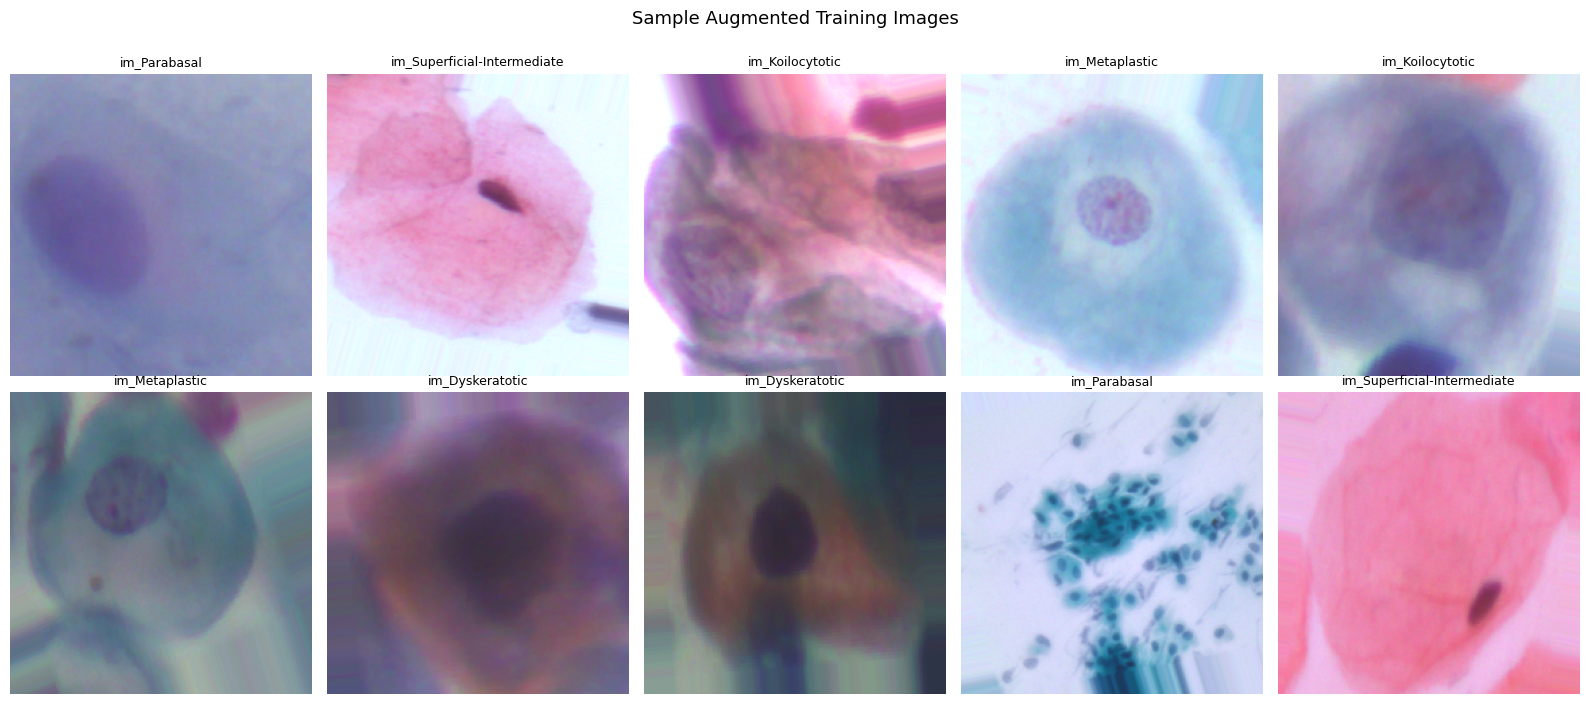

In [ ]:


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 7 — Visualise Sample Training Images                             ║
# ╚══════════════════════════════════════════════════════════════════════════╝

def show_samples(generator, idx_to_class, n=10):
    imgs, labels = next(generator)
    cols = 5
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 3.5 * rows))
    for i, ax in enumerate(axes.flat):
        if i >= n or i >= len(imgs):
            ax.axis('off')
            continue
        ax.imshow(imgs[i])
        ax.set_title(idx_to_class[np.argmax(labels[i])], fontsize=9)
        ax.axis('off')
    plt.suptitle("Sample Augmented Training Images", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

show_samples(train_gen, IDX_TO_CLASS)

In [ ]:


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 8 — Model 1: Baseline ResNet50                                   ║
# ╚══════════════════════════════════════════════════════════════════════════╝

def build_baseline(num_classes, img_size=(224, 224)):
    """
    ResNet50 pretrained on ImageNet.
    Backbone frozen; custom classification head added.
    """
    backbone = ResNet50(weights='imagenet', include_top=False,
                        input_shape=(*img_size, 3))
    backbone.trainable = False          # freeze all backbone layers

    inputs = keras.Input(shape=(*img_size, 3), name='input')
    x = backbone(inputs, training=False)
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu', name='fc1')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax',
                           name='predictions')(x)
    return Model(inputs, outputs, name='ResNet50_Baseline')


NUM_CLASSES    = len(CLASS_NAMES)
baseline_model = build_baseline(NUM_CLASSES)

baseline_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
baseline_model.summary()



Model: "ResNet50_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,121,733 (92.02 MB)

 Trainable params: 529,925 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 9 (FIXED) — Model 2: ResNet50 + CBAM  (Keras 3 compatible)      ║
# ╚══════════════════════════════════════════════════════════════════════════╝

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
import keras.ops as kops   # Keras 3 backend-agnostic ops


# ── Channel Attention ──────────────────────────────────────────────────────
def channel_attention(x, ratio=8):
    """
    Squeeze-and-Excitation style channel attention.
    Uses keras.ops instead of tf.* to stay inside the Keras graph.
    """
    channels = x.shape[-1]

    # Squeeze: global average & max pooling → (B, 1, 1, C)
    avg = layers.GlobalAveragePooling2D(keepdims=True)(x)  # (B,1,1,C)
    mx  = layers.GlobalMaxPooling2D(keepdims=True)(x)      # (B,1,1,C)

    # Shared MLP
    fc1 = layers.Dense(channels // ratio, activation='relu',  use_bias=False)
    fc2 = layers.Dense(channels,          activation=None,    use_bias=False)

    avg_out = fc2(fc1(avg))
    max_out = fc2(fc1(mx))

    # Excitation
    scale = layers.Activation('sigmoid')(layers.Add()([avg_out, max_out]))
    return layers.Multiply()([x, scale])


# ── Spatial Attention ──────────────────────────────────────────────────────
class SpatialAttention(layers.Layer):
    """
    Spatial attention using a wrapped Keras Layer so that
    keras.ops.mean / max work inside the functional graph.
    """
    def __init__(self, kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.kernel_size = kernel_size
        self.conv = layers.Conv2D(
            1, kernel_size, padding='same',
            activation='sigmoid', use_bias=False
        )

    def call(self, x):
        # Reduce along channel axis using keras.ops (graph-safe)
        avg_pool = kops.mean(x, axis=-1, keepdims=True)   # (B,H,W,1)
        max_pool = kops.max(x,  axis=-1, keepdims=True)   # (B,H,W,1)
        concat   = kops.concatenate([avg_pool, max_pool], axis=-1)  # (B,H,W,2)
        scale    = self.conv(concat)                       # (B,H,W,1)
        return x * scale

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'kernel_size': self.kernel_size})
        return cfg


# ── CBAM Block ─────────────────────────────────────────────────────────────
def cbam_block(x, ratio=8, kernel_size=7):
    """Full CBAM: channel attention → spatial attention."""
    x = channel_attention(x, ratio)
    x = SpatialAttention(kernel_size=kernel_size)(x)
    return x


# ── Build Model ────────────────────────────────────────────────────────────
def build_cbam_model(num_classes, img_size=(224, 224)):
    """ResNet50 (frozen) + CBAM on the final (7×7×2048) feature map."""
    backbone = ResNet50(
        weights='imagenet', include_top=False,
        input_shape=(*img_size, 3)
    )
    backbone.trainable = False

    inputs = keras.Input(shape=(*img_size, 3), name='input')
    x      = backbone(inputs, training=False)   # (B, 7, 7, 2048)
    x      = cbam_block(x)                      # channel + spatial attention
    x      = layers.GlobalAveragePooling2D(name='gap')(x)
    x      = layers.BatchNormalization()(x)
    x      = layers.Dense(256, activation='relu', name='fc1')(x)
    x      = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax',
                           name='predictions')(x)
    return Model(inputs, outputs, name='ResNet50_CBAM')


# ── Instantiate & compile ──────────────────────────────────────────────────
cbam_model = build_cbam_model(NUM_CLASSES)
cbam_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
cbam_model.summary()

Model: "ResNet50_CBAM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ input[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1, 1,      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1, 1,      │          0 │ resnet50[0][0]    │
│ (GlobalMaxPooling2… │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1, 1, 256) │    524,288 │ global_average_p… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1, 1,      │    524,288 │ dense[0][0],      │
│                     │ 2048)             │            │ dense[1][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 1,      │          0 │ dense_1[0][0],    │
│                     │ 2048)             │            │ dense_1[1][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1, 1,      │          0 │ add[0][0]         │
│ (Activation)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 7, 7,      │          0 │ resnet50[0][0],   │
│                     │ 2048)             │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_attention   │ (None, 7, 7,      │         98 │ multiply[0][0]    │
│ (SpatialAttention)  │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 2048)      │          0 │ spatial_attentio… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2048)      │      8,192 │ gap[0][0]         │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc1 (Dense)         │ (None, 256)       │    524,544 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ fc1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ predictions (Dense) │ (None, 5)         │      1,285 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,170,407 (96.02 MB)

 Trainable params: 1,578,599 (6.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [ ]:

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — Shared Callbacks Factory                                    ║
# ╚══════════════════════════════════════════════════════════════════════════╝

def get_callbacks(name):
    return [
        EarlyStopping(
            monitor='val_accuracy', patience=5,
            restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3,
            min_lr=1e-7, verbose=1
        ),
        ModelCheckpoint(
            filepath=f'/content/{name}_best.keras',
            monitor='val_accuracy', save_best_only=True, verbose=1
        ),
    ]

In [ ]:

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 11 — Train Baseline Model (Phase 1: frozen backbone)             ║
# ╚══════════════════════════════════════════════════════════════════════════╝

EPOCHS = 15

print("=" * 60)
print("Phase 1 — Training Baseline ResNet50 (frozen backbone)")
print("=" * 60)

hist_b1 = baseline_model.fit(
    train_gen, epochs=EPOCHS, validation_data=val_gen,
    callbacks=get_callbacks('baseline_p1'), verbose=1
)



Phase 1 — Training Baseline ResNet50 (frozen backbone)
Epoch 1/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.3203 - loss: 1.5281
Epoch 1: val_accuracy improved from None to 0.21242, saving model to /content/baseline_p1_best.keras

Epoch 1: finished saving model to /content/baseline_p1_best.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 995s 8s/step - accuracy: 0.4042 - loss: 1.4544 - val_accuracy: 0.2124 - val_loss: 1.7502 - learning_rate: 1.0000e-04
Epoch 2/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.5237 - loss: 1.3003
Epoch 2: val_accuracy improved from 0.21242 to 0.24048, saving model to /content/baseline_p1_best.keras

Epoch 2: finished saving model to /content/baseline_p1_best.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 1063s 8s/step - accuracy: 0.5327 - loss: 1.2609 - val_accuracy: 0.2405 - val_loss: 1.6481 - learning_rate: 1.0000e-04
Epoch 3/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.5667 - loss: 1.1679
Epoch 3: val_accuracy improved from 0.24048 to 0.38076, sa

In [ ]:

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 12 — Fine-tune Baseline (Phase 2: unfreeze top 30 layers)        ║
# ╚══════════════════════════════════════════════════════════════════════════╝

print("\nPhase 2 — Fine-tuning Baseline (top 30 ResNet layers unfrozen)")

baseline_model.get_layer('resnet50').trainable = True
for layer in baseline_model.get_layer('resnet50').layers[:-30]:
    layer.trainable = False

baseline_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

hist_b2 = baseline_model.fit(
    train_gen, epochs=10, validation_data=val_gen,
    callbacks=get_callbacks('baseline_ft'), verbose=1
)

# Merge phase-1 + phase-2 histories for a continuous plot
def merge(h1, h2):
    return {k: h1.history[k] + h2.history[k] for k in h1.history}

baseline_history = merge(hist_b1, hist_b2)


Phase 2 — Fine-tuning Baseline (top 30 ResNet layers unfrozen)
Epoch 1/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.5268 - loss: 1.5203
Epoch 1: val_accuracy improved from None to 0.21042, saving model to /content/baseline_ft_best.keras

Epoch 1: finished saving model to /content/baseline_ft_best.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 1295s 10s/step - accuracy: 0.5808 - loss: 1.3076 - val_accuracy: 0.2104 - val_loss: 17.4518 - learning_rate: 1.0000e-05
Epoch 2/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.6207 - loss: 1.0960
Epoch 2: val_accuracy improved from 0.21042 to 0.33467, saving model to /content/baseline_ft_best.keras

Epoch 2: finished saving model to /content/baseline_ft_best.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 1322s 10s/step - accuracy: 0.6197 - loss: 1.0862 - val_accuracy: 0.3347 - val_loss: 6.8485 - learning_rate: 1.0000e-05
Epoch 3/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.6424 - loss: 0.9819
Epoch 3: val_accuracy improved from 0.33467 t

In [ ]:


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 13 — Train CBAM Model (Phase 1 + Phase 2)                          ║
# ╚══════════════════════════════════════════════════════════════════════════╝

print("\n" + "=" * 60)
print("Phase 1 — Training CBAM Model (frozen backbone)")
print("=" * 60)

hist_c1 = cbam_model.fit(
    train_gen, epochs=EPOCHS, validation_data=val_gen,
    callbacks=get_callbacks('cbam_p1'), verbose=1
)

print("\nPhase 2 — Fine-tuning CBAM (top 30 ResNet layers unfrozen)")

cbam_model.get_layer('resnet50').trainable = True
for layer in cbam_model.get_layer('resnet50').layers[:-30]:
    layer.trainable = False

cbam_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

hist_c2 = cbam_model.fit(
    train_gen, epochs=10, validation_data=val_gen,
    callbacks=get_callbacks('cbam_ft'), verbose=1
)

cbam_history = merge(hist_c1, hist_c2)


Phase 1 — Training CBAM Model (frozen backbone)
Epoch 1/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.3093 - loss: 1.5557
Epoch 1: val_accuracy improved from None to 0.20040, saving model to /content/cbam_p1_best.keras

Epoch 1: finished saving model to /content/cbam_p1_best.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 952s 7s/step - accuracy: 0.3963 - loss: 1.4852 - val_accuracy: 0.2004 - val_loss: 1.6174 - learning_rate: 1.0000e-04
Epoch 2/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.5325 - loss: 1.2700
Epoch 2: val_accuracy did not improve from 0.20040
126/126 ━━━━━━━━━━━━━━━━━━━━ 992s 8s/step - accuracy: 0.5551 - loss: 1.1905 - val_accuracy: 0.1804 - val_loss: 1.6053 - learning_rate: 1.0000e-04
Epoch 3/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.6045 - loss: 1.0714
Epoch 3: val_accuracy did not improve from 0.20040
126/126 ━━━━━━━━━━━━━━━━━━━━ 984s 8s/step - accuracy: 0.6170 - loss: 1.0359 - val_accuracy: 0.1884 - val_loss: 2.1106 - learning_rate: 1.0000e

In [ ]:

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 14 — Plot Training Histories                                       ║
# ╚══════════════════════════════════════════════════════════════════════════╝

def plot_history(history_dict, title, acc_color='steelblue', loss_color='tomato'):
    ep = range(1, len(history_dict['accuracy']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(ep, history_dict['accuracy'],     color=acc_color,        lw=2, label='Train')
    ax1.plot(ep, history_dict['val_accuracy'], color=acc_color, ls='--', lw=2, label='Val')
    ax1.set_title(f'{title} — Accuracy');  ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy');            ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(ep, history_dict['loss'],     color=loss_color,        lw=2, label='Train')
    ax2.plot(ep, history_dict['val_loss'], color=loss_color, ls='--', lw=2, label='Val')
    ax2.set_title(f'{title} — Loss');      ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss');                ax2.legend(); ax2.grid(alpha=0.3)

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()


plot_history(baseline_history, 'Baseline ResNet50',  'steelblue',  'royalblue')
plot_history(cbam_history,     'ResNet50 + CBAM',    'darkorange', 'orangered')

In [ ]:


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 15 — Evaluate Both Models on Test Set                              ║
# ╚══════════════════════════════════════════════════════════════════════════╝

def evaluate(model, test_gen, class_names, model_name):
    print(f"\n{'=' * 60}")
    print(f"  {model_name}")
    print('=' * 60)

    test_gen.reset()
    loss, acc = model.evaluate(test_gen, verbose=0)
    print(f"  Test Loss     : {loss:.4f}")
    print(f"  Test Accuracy : {acc*100:.2f} %")

    test_gen.reset()
    y_prob = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = test_gen.classes

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name}', fontsize=13)
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout(); plt.show()

    return acc, y_pred, y_true


acc_base, pred_base, true_base = evaluate(
    baseline_model, test_gen, CLASS_NAMES, 'Baseline ResNet50')

acc_cbam, pred_cbam, true_cbam = evaluate(
    cbam_model, test_gen, CLASS_NAMES, 'ResNet50 + CBAM')


In [ ]:


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 16 — Side-by-Side Model Comparison Chart                           ║
# ╚══════════════════════════════════════════════════════════════════════════╝

model_names = ['Baseline\nResNet50', 'ResNet50\n+ CBAM']
accs        = [acc_base * 100, acc_cbam * 100]
colors      = ['steelblue', 'darkorange']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(model_names, accs, color=colors, edgecolor='black',
              width=0.4, zorder=3)
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val:.2f} %', ha='center', fontweight='bold', fontsize=12)

ax.set_ylim(0, 105)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Baseline vs CBAM Attention — Test Accuracy', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3, zorder=0)
plt.tight_layout(); plt.show()

delta = acc_cbam - acc_base
print(f"\nBaseline accuracy : {acc_base*100:.2f} %")
print(f"CBAM accuracy     : {acc_cbam*100:.2f} %")
print(f"Improvement       : {delta*100:+.2f} %")


In [ ]:

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 17 — Grad-CAM Implementation                                       ║
# ╚══════════════════════════════════════════════════════════════════════════╝

def compute_gradcam(model, img_array):
    """
    Compute Grad-CAM heatmap by targeting the last Conv2D layer
    inside the ResNet50 sub-model.

    img_array : numpy array of shape (1, H, W, 3), values in [0, 1]
    Returns   : heatmap (H', W') normalised to [0, 1]
    """
    resnet = model.get_layer('resnet50')

    # Find last Conv2D inside ResNet50
    last_conv = [l for l in resnet.layers
                 if isinstance(l, layers.Conv2D)][-1]

    # Sub-model: input -> (last conv output, resnet output)
    resnet_grad_model = Model(
        inputs=resnet.inputs,
        outputs=[resnet.get_layer(last_conv.name).output, resnet.output]
    )

    with tf.GradientTape() as tape:
        conv_out, resnet_out = resnet_grad_model(img_array)
        tape.watch(conv_out)

        # Pass resnet output through the remaining top layers
        x = resnet_out
        for lyr in model.layers:
            if lyr.name in {'input', 'resnet50'}:
                continue
            x = lyr(x)

        pred_idx    = tf.argmax(x[0])
        class_score = x[:, pred_idx]

    grads       = tape.gradient(class_score, conv_out)
    pooled      = tf.reduce_mean(grads, axis=(0, 1, 2))          # (C,)
    heatmap_raw = tf.squeeze(conv_out[0] @ pooled[..., tf.newaxis])  # (H', W')
    heatmap     = tf.maximum(heatmap_raw, 0)
    heatmap     = (heatmap / (tf.reduce_max(heatmap) + 1e-8)).numpy()
    return heatmap, int(pred_idx.numpy())


def overlay_heatmap(img, heatmap, alpha=0.45):
    """Resize heatmap to image size and overlay with jet colormap."""
    h_resized = np.array(
        tf.image.resize(heatmap[..., np.newaxis], img.shape[:2])
    ).squeeze()
    colormap   = cm.get_cmap('jet')
    heatmap_c  = colormap(h_resized)[:, :, :3]
    superimposed = np.clip(heatmap_c * alpha + img, 0, 1)
    return superimposed


def show_gradcam(model, test_gen, idx_to_class, model_name, n_samples=5):
    """Display Grad-CAM visualisations for n_samples random test images."""
    test_gen.reset()
    imgs_batch, lbl_batch = next(test_gen)
    indices = random.sample(range(len(imgs_batch)), min(n_samples, len(imgs_batch)))

    fig, axes = plt.subplots(n_samples, 3, figsize=(13, 4.5 * n_samples))
    fig.suptitle(f'Grad-CAM — {model_name}',
                 fontsize=14, fontweight='bold', y=1.01)

    for row, idx in enumerate(indices):
        img       = imgs_batch[idx]
        true_cls  = idx_to_class[np.argmax(lbl_batch[idx])]
        img_input = np.expand_dims(img, 0)

        heatmap, pred_idx = compute_gradcam(model, img_input)
        pred_cls  = idx_to_class[pred_idx]
        pred_conf = model.predict(img_input, verbose=0)[0][pred_idx]
        overlay   = overlay_heatmap(img, heatmap)
        correct   = "✓" if pred_cls == true_cls else "✗"

        axes[row, 0].imshow(img)
        axes[row, 0].set_title(f'Original\nTrue: {true_cls}', fontsize=9)
        axes[row, 0].axis('off')

        axes[row, 1].imshow(heatmap, cmap='jet')
        axes[row, 1].set_title('Grad-CAM Heatmap', fontsize=9)
        axes[row, 1].axis('off')

        axes[row, 2].imshow(overlay)
        axes[row, 2].set_title(
            f'Overlay  {correct}\nPred: {pred_cls} ({pred_conf:.2f})', fontsize=9)
        axes[row, 2].axis('off')

    plt.tight_layout(); plt.show()


print("Generating Grad-CAM for Baseline model …")
show_gradcam(baseline_model, test_gen, IDX_TO_CLASS, 'Baseline ResNet50')

print("Generating Grad-CAM for CBAM model …")
show_gradcam(cbam_model, test_gen, IDX_TO_CLASS, 'ResNet50 + CBAM')


In [ ]:

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 18 — Save Models (Colab + optionally back to Drive)                ║
# ╚══════════════════════════════════════════════════════════════════════════╝

baseline_model.save('/content/baseline_resnet50_final.keras')
cbam_model.save('/content/cbam_resnet50_final.keras')
print("Models saved to /content/")

# --- Optional: copy to Google Drive for persistence ---
SAVE_TO_DRIVE = True   # set False to skip
DRIVE_SAVE_DIR = '/content/drive/MyDrive/SIPaKMeD_Models'

if SAVE_TO_DRIVE:
    os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)
    shutil.copy('/content/baseline_resnet50_final.keras',
                os.path.join(DRIVE_SAVE_DIR, 'baseline_resnet50_final.keras'))
    shutil.copy('/content/cbam_resnet50_final.keras',
                os.path.join(DRIVE_SAVE_DIR, 'cbam_resnet50_final.keras'))
    print(f"Models also saved to Drive: {DRIVE_SAVE_DIR}")

In [ ]:



# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 19 — Final Summary                                                 ║
# ╚══════════════════════════════════════════════════════════════════════════╝

print("\n" + "=" * 62)
print("              FINAL RESULTS SUMMARY")
print("=" * 62)
print(f"  Dataset     : SIPaKMeD  ({total_images} images, 5 classes)")
print(f"  Input size  : {IMG_SIZE[0]}×{IMG_SIZE[1]}  |  Batch: {BATCH_SIZE}")
print(f"  Split       : 80 % train / 10 % val / 10 % test")
print("-" * 62)
print(f"  Baseline ResNet50 Test Accuracy : {acc_base*100:.2f} %")
print(f"  ResNet50 + CBAM  Test Accuracy  : {acc_cbam*100:.2f} %")
print(f"  Gain from Attention (CBAM)      : {(acc_cbam - acc_base)*100:+.2f} %")
print("=" * 62)